# Routing | Orchestrator | Evaluator Optimizer

In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


<br><hr>

# Routing

<br>

<img src="https://i.postimg.cc/KvcqZ0hY/image.png" width=300> </img>

<br>

- Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. 

- This is typically implemented using:

  - `add_conditional_edges`: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

  - `State`: The workflow’s state can store variables that influence routing decisions.

  - `Condition Functions`: Functions that evaluate the state or node output to decide the next step.

### Key Concepts

- `Dynamic Flow`: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- `Condition Logic`: You define rules (e.g., "if this, go here; if that, go there").

- `Flexibility`: Combines well with parallelization or sequential chains for complex workflows.

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

In [6]:
from IPython.display import Image, Markdown, display
from langchain_core.runnables import RunnableConfig
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

### Create A Simple Graph

In [7]:
from enum import Enum
from pydantic import BaseModel, Field


type PydanticModel = type[BaseModel]


class Topics(str, Enum):
    SPORTS = "sports"
    TECHNOLOGY = "technology"
    RELIGION = "religion"
    OTHERS = "others"


class State(TypedDict):
    user_input: str
    router_output: Topics
    final_story: str


class TopicsSchema(BaseModel):
    topic: Topics = Field(..., description="The topic of the story")


valid_topics: list[str] = [topic.value for topic in Topics if topic != Topics.OTHERS]

# ==================================================================
# ============================ PROMPTS =============================
# ==================================================================
sports_prompt: str = """
<INSTR>
You're a helpful sports writer. Create a short story of about 2 sentences about this 
<USER_INPUT>{user_input}</USER_INPUT>
</INSTR> 
"""

technology_prompt: str = """
<INSTR>
You're a helpful technology writer. Create a short story of about 2 sentences about this 
<USER_INPUT>{user_input}</USER_INPUT>
</INSTR> 
"""

religion_prompt: str = """
<INSTR>
You're a helpful religion writer. Create a short story of about 2 sentences about this 
<USER_INPUT>{user_input}</USER_INPUT>

<GUIDELINES>
1. Be concise and stay on topic.
2. Use clear and simple language.
3. This is a sensitive topic; approach with respect and neutrality.
</GUIDELINES>
</INSTR> 
"""

others_prompt: str = """
<INSTR>
You're a friendly assistant that helps users create short stories based on the: 
<TOPICS>{topics}</TOPICS>

<GUIDELINES>
- Ask the user about which topic they would like a story on.
- Your response should ONLY be a question about the topic they want.
</GUIDELINES>
</INSTR> 
"""


remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.85,
    model=RemoteModel.X_AI_GROK_4_FAST,
)

_router_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.GEMINI_2_0_FLASH_001,
)


async def router_llm(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    llm_with_structured_output = _router_llm.with_structured_output(TopicsSchema)
    response = await llm_with_structured_output.ainvoke(input=state["user_input"])

    return {"router_output": response.topic}


async def call_llm_1(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = sports_prompt.format(user_input=state["user_input"])
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


async def call_llm_2(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = technology_prompt.format(user_input=state["user_input"])
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


async def call_llm_3(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = religion_prompt.format(user_input=state["user_input"])
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


async def call_llm_4(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = others_prompt.format(topics=valid_topics)
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


def decide_next_node(
    state: State,
) -> Literal["call_llm_1", "call_llm_2", "call_llm_3", "call_llm_4"]:
    """Decide the next node based on the router output."""
    topic: Topics = state.get("router_output", Topics.OTHERS)

    if topic == Topics.SPORTS:
        return "call_llm_1"
    if topic == Topics.TECHNOLOGY:
        return "call_llm_2"
    if topic == Topics.RELIGION:
        return "call_llm_3"
    return "call_llm_4"

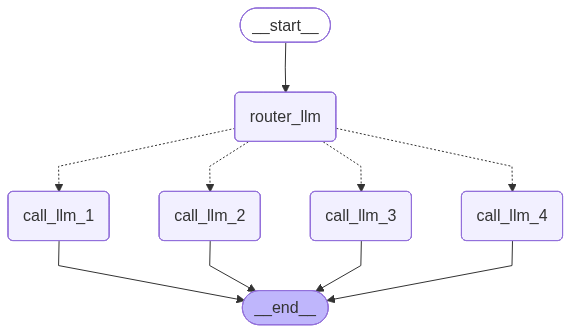

In [8]:
builder = StateGraph(State)

# Nodes
builder.add_node("router_llm", router_llm)
builder.add_node("call_llm_1", call_llm_1)
builder.add_node("call_llm_2", call_llm_2)
builder.add_node("call_llm_3", call_llm_3)
builder.add_node("call_llm_4", call_llm_4)


# Edges
builder.add_edge(START, "router_llm")
builder.add_conditional_edges("router_llm", decide_next_node)
builder.add_edge("call_llm_1", END)
builder.add_edge("call_llm_2", END)
builder.add_edge("call_llm_3", END)
builder.add_edge("call_llm_4", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph using nest_asyncio to handle event loop
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [9]:
# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"user_input": "Rev. Fr. Patrick"},
    config=config,
)

console.print(response)

{
    'user_input': 'Rev. Fr. Patrick',
    'router_output': <Topics.RELIGION: 'religion'>,
    'final_story': 'Rev. Fr. Patrick, a devoted priest in a quiet village church, spent his days guiding his flock 
with gentle wisdom and unwavering faith. One rainy afternoon, he comforted a grieving widow by sharing stories of 
hope from the scriptures, reminding her that even in sorrow, divine light always shines through.'
}

In [10]:
Markdown(response["final_story"])

Rev. Fr. Patrick, a devoted priest in a quiet village church, spent his days guiding his flock with gentle wisdom and unwavering faith. One rainy afternoon, he comforted a grieving widow by sharing stories of hope from the scriptures, reminding her that even in sorrow, divine light always shines through.

<br><hr>

# Orchestrator

In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

## When to use this workflow

- This workflow is well-suited for complex tasks where you can't predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). 

- Although it shares a comparable topology, the primary distinction from parallelization lies in its adaptability. Subtasks are **not fixed** in advance but **dynamically assigned** by the orchestrator according to the particular input.

<br>

[![image.png](https://i.postimg.cc/Z5nfGmWY/image.png)](https://postimg.cc/MnkbBh0g)

### Creating Workers Dynamically In LangGraph

- Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input.

- Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph.

- This gives the orchestrator access to all worker output and allows it to synthesize them into a final output.

- `Send` is used to create and send inputs to worker nodes dynamically.

<br>

  ```py
  from langgraph.constants import Send
  ```

<br>

In [ ]:
from __future__ import annotations  # noqa: F404

import operator


# ==================================================================
# ============================ STATES ==============================
# ==================================================================
class State(TypedDict):
    """Overall state"""

    topic: str

    # The task will be broken to chunks dynamically
    sections: list[Section]

    # Each completed task will be written to this key in parallel
    # Using 'add' operator instead of 'add_messages' since we're working with strings, not messages
    completed_sections: Annotated[list[str], operator.add]

    # Final output will be written here
    final_output: str


class WorkerState(TypedDict):
    """Independent worker state"""

    # The section being worked on
    section: Section
    # The list of already completed sections. It MUST have the same key name as in the overall state
    completed_sections: Annotated[list[str], operator.add]


# ==================================================================
# ============================ SCHEMA ==============================
# ==================================================================
class Section(BaseModel):
    name: str = Field(description="The name of the section of the report")
    description: str = Field(description="Brief overview of the main topics and concepts of the section")


class Sections(BaseModel):
    sections: list[Section] = Field(default_factory=list, description="A list of sections")


# ==================================================================
# ============================ PROMPTS =============================
# ==================================================================
orchestrator_prompt: str = """ 
<INSTR>
    <ROLE>Your're an expert planner that specializes in creating plans for a given report topic</ROLE>
    Create a plan to be used for creating this report topic
    <TOPIC>{topic}</TOPIC>

    <GUIDELINES>
        - Do not use create more than 5 sections
    </GUIDELINES>
</INSTR>
"""

worker_prompt: str = """ 
<INSTR>
    <ROLE>Your're an expert report writer that specializes in creating reports</ROLE>
    Create a report section with the: 
    <TOPIC>{topic}</TOPIC> and 
    <DESCRIPTION>{description}</DESCRIPTION>

    <GUIDELINES>
        - Do not use any preamble. Go straight to the point
        - Format the report headings and body using markdown format
    </GUIDELINES>
</INSTR>
"""


# ==================================================================
# ============================== LLMS ==============================
# ==================================================================
creative_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=1.5,
    model=RemoteModel.GPT_OSS_120B,
)

rigid_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.GEMINI_2_0_FLASH_001,
)

In [12]:
from langgraph.constants import Send

In [ ]:
# ==================================================================
# ============================ NODES ===============================
# ==================================================================
async def orchestrator_llm(state: State) -> dict[str, Any]:
    """Orchestrator LLM that creates the plan for the report."""
    prompt: str = orchestrator_prompt.format(topic=state["topic"])
    llm_with_structured_output = rigid_llm.with_structured_output(Sections)
    response = await llm_with_structured_output.ainvoke(input=prompt)

    return {"sections": response.sections}


async def worker_llm(state: WorkerState) -> dict[str, Any]:
    """Worker LLM that creates a section of the report.

    It expects a `section` as input
    """
    prompt: str = worker_prompt.format(topic=state["section"].name, description=state["section"].description)
    response = await creative_llm.ainvoke(input=prompt)

    return {"completed_sections": [response.content]}


# Conditional Node
def assign_workers(state: State) -> list[Any]:
    """Assign a worker to each section in the plan"""

    # Dynamically create the reports in parallel.
    # Send the `section` to each worker node
    return [Send("worker_llm", {"section": s}) for s in state["sections"]]


# Final Node
def synthesizer(state: State) -> dict[str, str]:
    """Synthesize full report from sections"""

    # List of completed sections - now these are just strings!
    completed_sections: list[str] = state["completed_sections"]

    # Filter out any empty strings
    completed_sections = [c for c in completed_sections if c]

    # Format completed section to str to use as context for final sections
    # i.e convert from list[str] -> str
    completed_report_sections: str = "\n\n---\n\n".join(completed_sections)

    return {"final_output": completed_report_sections}

In [14]:
builder: StateGraph = StateGraph(State)

# Nodes
builder.add_node("orchestrator_llm", orchestrator_llm)
builder.add_node("worker_llm", worker_llm)
builder.add_node("synthesizer", synthesizer)


# Edges
builder.add_edge(START, "orchestrator_llm")
builder.add_conditional_edges("orchestrator_llm", assign_workers, ["worker_llm"])
builder.add_edge("worker_llm", "synthesizer")
builder.add_edge("synthesizer", END)

# Compile the graph
memory = MemorySaver()
orchestrator_graph = builder.compile(checkpointer=memory)

# Visualize the graph with ASCII fallback
try:
    display(Image(orchestrator_graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    try:
        print(orchestrator_graph.get_graph(xray=1).draw_ascii())
    except ImportError as ie:
        console.print(f"[red]ASCII visualization also failed: {ie}[/red]")
        console.print("[magenta]Showing basic graph structure:[/magenta]\n")
        graph_obj = orchestrator_graph.get_graph(xray=1)
        console.print(f"Nodes: {[node.id for node in graph_obj.nodes.values()]}")
        console.print(f"Edges: {[(e.source, e.target) for e in graph_obj.edges]}")

PNG visualization failed: Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 
204.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., 
draw_method=MermaidDrawMethod.PYPPETEER)`

Displaying ASCII representation instead:

    +-----------+    
    | __start__ |    
    +-----------+    
          *          
          *          
          *          
+------------------+ 
| orchestrator_llm | 
+------------------+ 
          .          
          .          
          .          
   +------------+    
   | worker_llm |    
   +------------+    
          *          
          *          
          *          
  +-------------+    
  | synthesizer |    
  +-------------+    
          *          
          *          
          *          
    +---------+      
    | __end__ |      
    +---------+      


In [15]:
# Re-build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "2"}}

response = await graph.ainvoke(
    {"topic": "Recall while studying"},
    config=config,
)

# console.print(response)

In [16]:
Markdown(response["final_output"])

## Introduction to Recall in Studying  

**Definition**  
Recall is the cognitive process of retrieving information that has been previously encoded and stored in memory. In an academic context, it reflects a learner’s ability to bring pertinent facts, concepts, or skills back into conscious awareness when needed—to answer a test question, write an essay, or apply knowledge in a new situation.

**Why It Matters**  
- **Academic performance:** High recall precision directly boosts grades on exams, essays, and practical assignments.  
- **Long‑term retention:** Effective recall consolidates knowledge from short‑term to long‑term memory, allowing information to be reused across courses, research, and professional practice.  
- **Transfer of learning:** Strong recall enables students to apply learned material in novel contexts, fostering deeper comprehension and problem‑solving ability.

**Key Factors Influencing Recall Ability**  
1. **Encoding Quality** – depth of processing, elaboration, and organization of the material during initial study.  
2. **Retention Interval** – length of time between learning and retrieval; longer intervals generally weaken recall unless reinforced.  
3. **Retrieval Practice** – the frequency and quality of self‑testing or spaced repetition activities.  
4. **Contextual Consistency** – similarity between learning environment and retrieval setting (context-dependent memory).  
5. **Emotional State & Motivation** – stress, anxiety, and personal interest can either hinder or enhance recall.  
6. **Physiological Factors** – sleep, nutrition, and overall health significantly affect neuronal consolidation pathways.  

These elements combine to shape how effectively a student can summon learned material when required.

---

## Cognitive Processes Underlying Recall  

### 1. Encoding  
- **Definition:** Transformation of sensory input into a mental representation that can be stored.  
- **Mechanisms:**  
  - *Semantic encoding* (meaning‑based) – yields deeper, more durable traces.  
  - *Phonological encoding* (sound) – dominant in verbal tasks.  
  - *Visual encoding* (image) – supports later pictorial retrieval.  
- **Facilitators:** Focused attention, elaborative rehearsal, and depth‑of‑processing (Craik & Lockhart, 1972).  

### 2. Storage  
| Memory System | Duration | Capacity | Typical Encoding Strategies |
|---------------|----------|----------|------------------------------|
| **Sensory (iconic, echoic)** | < 1 s – 2 s | Limited to raw stimulus | Immediate attentional capture |
| **Short‑Term / Working Memory** | 15–30 s (without rehearsal) | 4 ± 1 chunks (Miller, 1956) | Chunking, rehearsal, rehearsal digit span tasks |
| **Long‑Term Memory (LTM)** | Hours to lifetime | Effectively unlimited | Semantic networking, consolidation (sleep, neurological replay) |

- **Consolidation:** Stabilization of engrams through hippocampal–neocortical interaction; influenced by sleep, emotion, and neuromodulators (e.g., acetylcholine).  

### 3. Retrieval  
- **Cue‑Dependent Search:** Retrieval cues matching encoded features trigger access (Tulving's Encoding Specificity Principle).  
- **Recognition vs. Recall:** Recognition benefits from familiarity; recall requires generation of the target representation.  
- **Reconstruction:** Retrieval is an active reconstruction, susceptible to interference and distortion.  

### 4. Role of Attention  
- **Selective Attention:** Allocates processing resources to relevant inputs, boosting encoding fidelity.  
- **Sustained Attention:** Maintains information in working memory for bulkier processing.  
- **Divided Attention:** Impairs encoding and subsequent recall; multitasking reduces depth of processing (Mayer, 2001).  

### 5. Memory Systems Interaction  
1. **Sensory → Working Memory:** Initial trace retained via echoic/​iconic buffers.  
2. **Working ↔ Encoding Processes:** Manipulation (e.g., rehearsal) routes information to LTM.  
3. **Long‑Term Retrieval → Working Memory:** Reinstated traces are refreshed in working memory for conscious use.  

### 6. Cognitive Strategies that Enhance Recall  
| Strategy | Cognitive Mechanism | Empirical Support |
|----------|----------------------|-------------------|
| **Elaborative rehearsal** | Links new info to pre‑existing schemas → deeper semantic encoding | Bransford & Johnson (1972) |
| **Mnemonic devices (acrostics, loci)** | Provides structured retrieval cues |Bellezza, 1981 |
| **Spaced repetition** | Increases consolidation cycles, reduces interference | Cepeda et al., 2006 |
| **Testing effect (retrieval practice)** | Strengthens memory trace through active recall | Roediger & Karpicke, 2006 |
| **Dual‑coding** (visual + verbal) | Creates redundant memory traces across modalities | Paivio, 1991 |
| **Metacognitive monitoring** | Guides allocation of attention and rehearsal effort | Flavell, 1979 |

### 7. Integrated Process Flow  

```mermaid
flowchart LR
    A[Sensory Input] -->|Attention| B[Encoding]
    B --> C[Working Memory]
    C -->|Rehearsal/Chunking| D[Long‑Term Storage]
    D -->|Consolidation (sleep, emotion)| D
    D -->|Cue‑Dependent Retrieval| E[Recall]
    E -->|Reconstruction| F[Conscious Output]
    subgraph Strategies
        G[Elaborative Strategies]
        H[Spaced Repetition]
        I[Testing Effect]
    end
    G --> B
    H --> D
    I --> E
```

*The diagram illustrates how attention gates early encoding, how working memory structures the information for long‑term storage, and how retrieval cues and the strategic deployment of cognitive tactics culminate in successful recall.*

---

## Strategies to Enhance Recall While Studying  

### 1. Active Recall  
- **Self‑testing:** Pause after reading a paragraph and close the book; write down or speak everything you remember.  
- **Flashcards:** Use the “question → answer” format; review cards only after you’ve tried to retrieve the answer.  
- **Practice quizzes:** Create low‑stakes quizzes (online or paper) covering each topic unit.  
- **Teaching back:** Explain concepts aloud to a study partner or record yourself as if lecturing.

---

### 2. Spaced Repetition  
- **Scheduling repeats:** Review material at increasing intervals (e.g., 1 day, 3 days, 1 week, 2 weeks).  
- **Digital apps:** Employ tools such as Anki or Quizlet that automate spacing based on performance.  
- **Chunked sessions:** Break study material into manageable chunks and rotate them across days rather than mass‑cramming.  
- **Review logs:** Keep a brief log of what was reviewed and when, to verify spacing is maintained.

---

### 3. Elaboration  
- **Ask “why” and “how”:** For every fact, generate an explanation linking it to prior knowledge.  
- **Generate examples:** Create your own relevant examples or analogies for each concept.  
- **mind‑mapping:** Draw connections between ideas, showing cause‑effect or hierarchical relationships.  
- **Summarize in your own words:** Write a short paragraph summarizing a topic without looking at the source.

---

### 4. Mnemonic Devices  
- **Acronyms & acrostics:** Form a memorable word or sentence from the first letters of a list (e.g., **HOMES** for the Great Lakes).  
- **Chunking:** Group long strings of information into 3–5‑item chunks (e.g., phone numbers).  
- **Method of loci:** Visualize information placed along a familiar spatial route (your home, a walking path).  
- **Visualization & imagery:** Pair abstract concepts with vivid mental pictures or storylines.  

---

### Implementation Checklist  
- ☐ Choose 1–2 active‑recall techniques per study session.  
- ☐ Schedule repetitions using a spaced‑repetition planner or app.  
- ☐ After each review, write an elaborative summary (2‑3 sentences).  
- ☐ Attach a mnemonic to any list or sequence that feels hard to remember.  

By integrating these strategies systematically, students can shift from passive re‑reading to a more cognitively demanding, retrieval‑oriented workflow—dramatically boosting long‑term recall and exam performance.

---

## Environmental and Lifestyle Factors Affecting Recall  

### Study Environment  
**Impact**  
- Noise, inconsistent lighting, and clutter divert attention, reducing encoding efficiency.  
- Temperature extremes (too hot or cold) impair cortical processing, leading to shallower memory traces.  

**Recommendations**  
- Choose a quiet, dedicated space with minimal visual distractions.  
- Optimize lighting (natural daylight preferred; task lighting of 500–700 lux).  
- Maintain room temperature around 20 °C (68 °F).  
- Keep the desk organized; use a single, clearly defined work surface.

### Sleep  
**Impact**  
- Rapid‑eye‑movement (REM) and slow‑wave sleep consolidate declarative and procedural memories; deprivation truncates this process.  
- Fragmented sleep raises cortisol, hindering hippocampal replay.  

**Recommendations**  
- Aim for 7–9 hours of uninterrupted sleep per night.  
- Stick to consistent bedtime and wake‑time schedules, even on weekends.  
- Avoid screens, caffeine, and heavy meals at least 2 hours before bedtime.  
- Consider short (20‑90 min) daytime naps if nighttime sleep is insufficient.

### Stress  
**Impact**  
- Acute stress spikes catecholamines, which can enhance short‑term recall but impair long‑term consolidation.  
- Chronic stress elevates cortisol, damaging hippocampal neurons and reducing recall accuracy.  

**Recommendations**  
- Practice regular relaxation techniques (e.g., deep breathing, progressive muscle relaxation, or mindfulness meditation) for 10–15 minutes daily.  
- Schedule brief physical activity breaks (5‑10 minutes) to lower sympathetic arousal.  
- If under sustained pressure, use Eisenhower or Pomodoro methods to break tasks into manageable intervals, reducing perceived workload.

### Diet & Hydration  
**Impact**  
- Glucose is the primary fuel for neuronal activity; hypoglycemia impairs attention and retrieval.  
- Omega‑3 fatty acids, antioxidants (vitamins C, E), and flavonoids support synaptic plasticity and protect against oxidative stress.  
- Mild dehydration (~2 % body water loss) reduces cognition and slows processing speed.  

**Recommendations**  
- Eat balanced meals every 3‑4 hours containing protein, complex carbohydrates, and healthy fats.  
- Include brain‑boosting foods: fatty fish, nuts, seeds, berries, leafy greens, and olive oil.  
- Limit refined sugars, excessive caffeine, and highly processed foods that cause glucose spikes.  
- Drink ≈ 2 L (8 cups) of water daily; increase intake with physical activity or hot environments.  
- Consider a modest supplemental dose of EPA/DHA (≈ 1 g) if dietary intake is low.  

### Integrated Quick‑Check Checklist  

| Factor | Action Item | Frequency |
|--------|--------------|-----------|
| Environment | Declutter desk, set optimal lighting & temperature | Each study session |
| Sleep | 7–9 h nightly, consistent schedule | Daily |
| Stress | 10 min mindfulness + brief movement breaks | 2‑3 times per day |
| Diet | Balanced meals, hydration, brain‑food inclusion | Every 3–4 h (food) / Daily (water) |

Implementing these evidence‑based adjustments creates a supportive backdrop for encoding, consolidation, and retrieval, thereby strengthening overall recall performance.

---

## Conclusion: Maximizing Recall for Effective Learning  

**Key Strategies & Factors**  
- **Spaced Repetition:** Schedule review sessions at increasing intervals to strengthen neural pathways.  
- **Retrieval Practice:** Test yourself frequently rather than re‑reading notes; active recall solidifies memory.  
- **Multimodal Encoding:** Combine visual, auditory, and kinesthetic inputs (diagrams, recordings, hands‑on tasks) to create richer memory traces.  
- **Interleaving & Variable Practice:** Mix related topics during study sessions to improve discrimination and transfer.  
- **Elaborative Encoding:** Connect new information to prior knowledge, generate explanations, and ask “why” questions.  
- **Focused Attention:** Manage distractions, use pomodoro‑style blocks, and work in a consistent, low‑stimulus environment.  
- **Metacognitive Monitoring:** Regularly assess what you know and adjust study strategies accordingly.  

**Why Consistency & Personalization Matter**  
Consistent, daily practice prevents the forgetting curve from taking hold, while tailoring techniques to individual preferences (e.g., auditory learners using podcasts, visual learners using mind‑maps) maximizes the brain’s natural encoding mechanisms. A personalized, disciplined routine turns recall from a fleeting event into a reliable tool for long‑term mastery.

**Further Resources**  
- *Make It Stick: The Science of Successful Learning* – Brown, Roediger, & McDaniel  
- *Learning How to Learn* (Coursera) – Dr. Barbara Oakley & Dr. Terrence Sejnowski  
- ***Spaced Repetition Software***: Anki, SuperMemo, or Mnemosyne  
- *The Learning Scientists* blog and podcasts (https://www.learningscientists.org)  
- *Memory & You* – free open‑access MOOC on cognitive psychology (edX)

Continue applying these strategies, track progress, and adjust the approach as needed to sustain high‑impact learning results.

# Evaluator-Optimizer

In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

### When to use this workflow

- This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. 

- The two signs of good fit are:
  - first, that LLM responses can be demonstrably improved when a human articulates their feedback
  - second, that the LLM can provide such feedback. 
  
- This is analogous to the iterative writing process a human writer might go through when producing a polished document.

<br>

[![image.png](https://i.postimg.cc/PqKw8TBt/image.png)](https://postimg.cc/4K7dDkfM)

In [17]:
# ==================================================================
# ============================ STATES ==============================
# ==================================================================
class State(TypedDict):
    """Overall state"""

    topic: str
    joke: str
    runs: int
    feedback: dict[str, str]


class Rating(str, Enum):
    FUNNY = "funny"
    BORING = "boring"


# ==================================================================
# ============================ SCHEMA ==============================
# ==================================================================
class Feedback(BaseModel):
    rating: Rating = Field(description="The rating given to the response")
    reason: str = Field(description="The reason for the given rating")


# ==================================================================
# ============================ PROMPTS =============================
# ==================================================================
generator_prompt: str = """ 
<INSTR>
    <ROLE>Your're an expert comedian that specializes in telling jokes</ROLE>
    Create a short joke based on the:
    <TOPIC>{topic}</TOPIC>

    <GUIDELINES>
        - Do not use create more than 2 sentences
    </GUIDELINES>
</INSTR>
"""

evaluator_prompt: str = """ 
<INSTR>
    <ROLE>Your're an expert comedian that critiques jokes</ROLE>
    <JOKE>{joke}</JOKE>
</INSTR>
"""

improvement_prompt: str = """ 
<INSTR>
    <ROLE>Your're an expert comedian that specializes in telling jokes</ROLE>
    Create an improved version of the following joke: 
    <JOKE>{joke}</JOKE> based on the <TOPIC>{topic}</TOPIC> and 
    <REASON>{reason}</REASON>

    <GUIDELINES>
        - Do not diverge from the original joke's theme
        - Do not use more than 2 sentences
    </GUIDELINES>
</INSTR>
"""


# ==================================================================
# ============================== LLMS ==============================
# ==================================================================
creative_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=1.5,
    model=RemoteModel.DEEPSEEK_CHAT_V3_0324,
    timeout=15,
)

rigid_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.LLAMA_3_3_70B_INSTRUCT,
    timeout=15,
)

In [ ]:
# ==================================================================
# ============================= NODES ==============================
# ==================================================================
async def generator_llm(state: State) -> dict[str, Any]:
    """Generate a joke based on the topic."""
    runs: int = state.get("runs", 0)

    if state.get("feedback", None):
        state["runs"] = runs + 1
        prompt: str = improvement_prompt.format(topic=state["topic"], reason=state["feedback"]["reason"], joke=state["joke"])
        response = await creative_llm.ainvoke(input=prompt)
    else:
        prompt: str = generator_prompt.format(topic=state["topic"])
        response = await creative_llm.ainvoke(input=prompt)
    print(f"Joke generated in run {state.get('runs', 0)}: {response.content}")  # Debugging

    return {"joke": response.content, "runs": state["runs"] if "runs" in state else 0}


async def evaluator_llm(state: State) -> dict[str, Any]:
    """Evaluate the joke and provide feedback."""

    prompt: str = evaluator_prompt.format(joke=state["joke"])
    llm_with_structured_output = rigid_llm.with_structured_output(Feedback)
    response: PydanticModel = await llm_with_structured_output.ainvoke(input=prompt)
    return {
        "joke": state["joke"],
        "improved_story": state.get("improved_story", ""),
        "feedback": response.model_dump(),
    }


# Conditional node
def router(state: State) -> Literal["pass", "failed"]:
    """Route based on the feedback rating and number of runs."""
    rating: int = state["feedback"].get("rating", "boring")
    runs: int = state.get("runs", 0)

    if rating == Rating.FUNNY or runs >= 2:
        return "pass"
    return "failed"

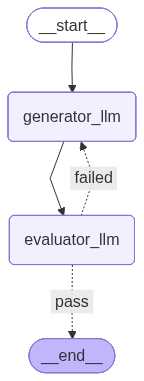

In [19]:
builder: StateGraph = StateGraph(State)

# Nodes
builder.add_node("generator_llm", generator_llm)
builder.add_node("evaluator_llm", evaluator_llm)


# Edges
builder.add_edge(START, "generator_llm")
builder.add_edge("generator_llm", "evaluator_llm")
builder.add_conditional_edges(
    "evaluator_llm",
    router,
    {"pass": END, "failed": "generator_llm"},
)
builder.add_edge("generator_llm", END)
# Redundant edge to END
builder.add_edge("evaluator_llm", END)


# Compile the graph
memory = MemorySaver()
evaluator_graph = builder.compile(checkpointer=memory)

# Visualize the graph with ASCII fallback
try:
    display(Image(evaluator_graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    try:
        print(evaluator_graph.get_graph(xray=1).draw_ascii())
    except ImportError as ie:
        console.print(f"[red]ASCII visualization also failed: {ie}[/red]")
        console.print("[magenta]Showing basic graph structure:[/magenta]\n")
        graph_obj = evaluator_graph.get_graph(xray=1)
        console.print(f"Nodes: {[node.id for node in graph_obj.nodes.values()]}")
        console.print(f"Edges: {[(e.source, e.target) for e in graph_obj.edges]}")

In [20]:
# Re-build the graph
memory = MemorySaver()
evaluator_graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "2"}}

response = await evaluator_graph.ainvoke({"topic": "p-square"}, config=config)

console.print(response)

Joke generated in run 0: Why did P-Square break up? Because they couldn’t find the right "angle" to keep their partnership going! *ba-dum-tss*


{
    'topic': 'p-square',
    'joke': 'Why did P-Square break up? Because they couldn’t find the right "angle" to keep their partnership 
going! *ba-dum-tss*',
    'runs': 0,
    'feedback': {
        'rating': <Rating.FUNNY: 'funny'>,
        'reason': "The joke is a play on words, using the mathematical term 'angle' to make a pun on the duo's name
'P-Square', which is a clever and unexpected twist that creates humor."
    }
}

In [ ]:
import sqlite3
from typing import TypedDict

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


class FormState(TypedDict):
    age: int | None


def get_age_node(state: FormState):
    prompt = "What is your age?"

    while True:
        answer = interrupt(prompt)  # payload surfaces in result["__interrupt__"]

        if isinstance(answer, int) and answer > 0:
            return {"age": answer}

        prompt = f"'{answer}' is not a valid age. Please enter a positive number."


builder = StateGraph(FormState)
builder.add_node("collect_age", get_age_node)
builder.add_edge(START, "collect_age")
builder.add_edge("collect_age", END)

checkpointer = SqliteSaver(sqlite3.connect("forms.db"))
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "form-1"}}
first = graph.invoke({"age": None}, config=config)
print(first["__interrupt__"])  # -> [Interrupt(value='What is your age?', ...)]

# Provide invalid data; the node re-prompts
retry = graph.invoke(Command(resume="thirty"), config=config)
print(retry["__interrupt__"])  # -> [Interrupt(value="'thirty' is not a valid age...", ...)]

# Provide valid data; loop exits and state updates
final = graph.invoke(Command(resume=30), config=config)
print(final["age"])  # -> 30